# B-XAIC Training Notebook

This Notebook is for training GNNs on specified tasks of the B-XAIC dataset. 

There is a total of seven different tasks to learn:

| task | prediction | difficulty |
| :--- | :--- | :--- |
| B| Does the molecule contain B atoms? | very easy |
| P | Does the molecule contain P atoms? | sehr leicht |
| X | Does the molecule contain any halogen atoms? | easy |
| indole| Does the molecule contain indole rings? | average |
| PAINS | Does the molecule contain "pan-assay interference compounds"? | hard |
| rings-count | Does the molecule contain more than four rings? | very hard |
| rings-max | Does the molecule contain large rings with more than six atoms? | very hard |


You can specify which task should be loaded and what type of model to train.
The model will have 3 layers.

The finished model will be saved to file so that you can use it for the explanation Notebook.<br />
=> /models/b-xaic/TASK

The training results (accuracy and loss plots) will be displayed and also saved to files.<br />
=> /training_plots/b-xaic/TASK


Important Note: One of the files neccessary for loading the dataset (explanations.sdf) is too large for git.<br />
You have to go to the link of the dataset, provided below, and download explanations.sdf.<br />
Put the file in the folder => /b-xaic


Github: https://github.com/mproszewska/B-XAIC <br />
Paper: https://arxiv.org/abs/2505.22252 <br />
Datensatz: https://huggingface.co/datasets/mproszewska/B-XAIC/tree/main <br />

## 0. Imports and Seeding

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch.utils.data import Subset, WeightedRandomSampler
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import Sequential, GCN, GAT, GIN, global_add_pool

from rdkit.Chem import BondType
from rdkit import Chem

from tqdm import tqdm
from sklearn.metrics import f1_score

from matplotlib import pyplot as plt

import copy
import random

In [2]:
seed = 123

np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Load Data

### - Specify the task you want to train on here! - 

In [3]:
"""
Possible tasks:

    "B",
    "P",
    "X",
    "indole",
    "PAINS",
    "rings-count",
    "rings-max"

"""

TASK = "indole"

In [4]:
df = pd.read_csv("b-xaic/data.csv")
path_to_local_explamnations_sdf = "b-xaic/explanations.sdf"
print(df.shape)
print(df.columns.tolist())

(50000, 15)
['Unnamed: 0', 'ChEMBL ID', 'smiles', 'rings-count', 'rings-max', 'X', 'P', 'B', 'indole', 'PAINS', 'split_0', 'split_1', 'split_2', 'split_3', 'split_4']


In [5]:
# aus https://github.com/mproszewska/B-XAIC/blob/main/dataset.py
TASKS = ["B", "P", "X", "indole", "PAINS", "rings-count", "rings-max"]
SYMBOLS = ["C", "N", "O", "F", "Cl", "Br", "P", "S", "B", "I", "Unk"]
# Mapping: Task-Name => Property-Name für die explanations.sdf
TASK_TO_PROP = {
    "B":           "B",
    "P":           "P",
    "X":           "X",
    "indole":      "indole",
    "PAINS":       "pains",
    "rings-count": "rings",
    "rings-max":   "largest_rings",
}

In [6]:
print(f"Dataset: {len(df):,} molecules, {df['smiles'].nunique():,} unique SMILES")
print(f"Avg. atoms per molecule (proxy via SMILES length): {df['smiles'].str.len().mean():.1f} chars\n")

print("Task label distribution (% positiv))") # wie auf S.5 im paper
for task in TASKS:
    bar = "█" * int(df[task].mean() * 30)
    print(f"  {task:12s} {df[task].mean():5.1%}  {bar}")

print(f"\nSplit (split_0):")
print(df["split_0"].value_counts().to_string())

Dataset: 50,000 molecules, 50,000 unique SMILES
Avg. atoms per molecule (proxy via SMILES length): 66.9 chars

Task label distribution (% positiv))
  B             2.2%  
  P            13.2%  ███
  X            55.9%  ████████████████
  indole       36.8%  ███████████
  PAINS        32.9%  █████████
  rings-count  30.1%  █████████
  rings-max     5.7%  █

Split (split_0):
split_0
train    40000
valid     5000
test      5000


In [7]:
def atom_label(atom):
    sym = atom.GetSymbol()
    return SYMBOLS.index(sym) if sym in SYMBOLS else len(SYMBOLS) - 1

def bond_type_to_int(bond_type):
    if bond_type == BondType.SINGLE:   return 0
    elif bond_type == BondType.DOUBLE: return 1
    elif bond_type == BondType.TRIPLE: return 2
    elif bond_type == BondType.AROMATIC: return 3
    else: return -1

def smiles_to_graph(mol):
    x = F.one_hot(
        torch.tensor([atom_label(atom) for atom in mol.GetAtoms()], dtype=torch.long),
        len(SYMBOLS),
    ).float()

    row, col, edge_labels = [], [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        row += [i, j]
        col += [j, i]
        edge_type = bond_type_to_int(bond.GetBondType())
        edge_labels += [edge_type, edge_type]

    edge_index = torch.tensor([row, col], dtype=torch.long)
    edge_attr  = torch.tensor(edge_labels, dtype=torch.long).view(-1, 1)
    return x, edge_index, edge_attr

In [8]:
""" 
Building the Dataset from the file. 
The dataset is a list of Data objects.
The nodes are atoms and the edges are bonds.
For more complex tasks, additional edge properties are added.

Additionally, the dataset size and average density are printed.
"""

property = TASK_TO_PROP[TASK]

splits = df[[f"split_{i}" for i in range(5)]]
ys     = torch.tensor(df[TASK].tolist()).unsqueeze(1)

dataset = []
skipped = 0

avg_density = 0

with Chem.SDMolSupplier(path_to_local_explamnations_sdf, sanitize=False) as suppl:
    for y, mol in tqdm(zip(ys, suppl), total=len(ys)):
        if mol is None:
            skipped += 1
            continue

        x, edge_index, edge_attr = smiles_to_graph(mol)

        p = mol.GetProp(property)
        expl_node_mask = torch.zeros(len(x), dtype=torch.bool)
        if p != "":
            nodes = torch.tensor([int(n) for n in p.split(",")], dtype=torch.long)
            expl_node_mask[nodes] = True

        if property not in ["B", "P", "X"]:
            p = mol.GetProp(f"{property}_edge")
            expl_edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
            if p != "":
                edges = {(int(e1), int(e2)) for e1, e2 in [e.split("#") for e in p.split(",")]}
                for i in range(edge_index.shape[1]):
                    e1, e2 = edge_index[0, i].item(), edge_index[1, i].item()
                    expl_edge_mask[i] = (e1, e2) in edges or (e2, e1) in edges
        else:
            expl_edge_mask = None
        
        graph = Data(
            x=x, edge_index=edge_index, edge_attr=edge_attr, y=y,
            expl_node_mask=expl_node_mask, expl_edge_mask=expl_edge_mask,
        )
        dataset.append(graph)
        density = 2 * graph.num_edges / (graph.num_nodes-1)*graph.num_nodes
        avg_density += density/50_000


print(f"Total number of graphs : {len(dataset)}")
print(f"Average Graph Density of Dataset : {avg_density:.2f}")

100%|██████████| 50000/50000 [00:22<00:00, 2213.35it/s]

Total number of graphs : 50000
Average Graph Density of Dataset : 154.72


In [9]:
""" Splitting Dataset and creating Dataloaders """

SPLIT = 0
BATCH = 64

idx = torch.arange(len(splits))
split_col = splits[f"split_{SPLIT}"]
train_idx = idx[split_col == "train"]
val_idx   = idx[split_col == "valid"]
test_idx  = idx[split_col == "test"]

train_set = Subset(dataset, train_idx)
val_set   = Subset(dataset, val_idx)
test_set  = Subset(dataset, test_idx)

y_train        = torch.cat([dataset[i].y for i in train_idx])
class_counts   = torch.bincount(y_train)
sample_weights = (1.0 / class_counts.float())[y_train]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

loader_train_sampler = DataLoader(train_set, batch_size=BATCH, sampler=sampler)
loader_train = DataLoader(train_set, batch_size=BATCH, shuffle=True)
loader_val   = DataLoader(val_set,   batch_size=BATCH, shuffle=False)
loader_test  = DataLoader(test_set,  batch_size=BATCH, shuffle=False)

print(f"Task: {TASK}  |  Split: {SPLIT}")
print(f"Train: {len(train_set)}  Val: {len(val_set)}  Test: {len(test_set)}")

Task: indole  |  Split: 0
Train: 40000  Val: 5000  Test: 5000


## 2. GCN, GAT, GIN definition

In [10]:
def get_model(model_type, num_node_features, num_classes,
              hidden_dim=32, num_layers=3, linear_dim=32):
    """
    Returns requested model.
    Either a Graph Convolutional Network, Graph Attention Network, or Graph Isomorphism Network.
    We use the torch classes for the models, with pooling and a classification head for graph level predicitons.
    For the GAT, we use the v2, as the normal GAT is very limited: https://arxiv.org/abs/2105.14491
    """

    if model_type == "GCN":
        model = Sequential("x, edge_index, batch", [
            (GCN(num_node_features, hidden_dim,
                 num_layers=num_layers, out_channels=linear_dim),
             "x, edge_index -> x"),
            (global_add_pool, "x, batch -> x"),
            Linear(linear_dim, num_classes),
        ])
    elif model_type == "GAT":
            model = Sequential("x, edge_index, batch", [
                (GAT(num_node_features, hidden_dim,
                    num_layers=num_layers, out_channels=linear_dim,
                    v2=True,
                    act="elu", dropout=0.6),
                "x, edge_index -> x"),
                (global_add_pool, "x, batch -> x"),
                Linear(linear_dim, num_classes),
            ])

    elif model_type == "GIN":
        model = Sequential("x, edge_index, batch", [
            (GIN(num_node_features, hidden_dim,
                 num_layers=num_layers, out_channels=linear_dim,
                 norm="batch_norm"),
             "x, edge_index -> x"),
            (global_add_pool, "x, batch -> x"),
            Linear(linear_dim, num_classes),
        ])

    return model

## 3. Training

In [11]:
def train(model, optimizer, dataloader, device):
    """
    Training loop for single epoch.
    Takes a loader, the model to train, an optimizer and criterion, and trains the given model for every item in the dataset.
    Returns the loss of the epoch.
    """
    model.train()
    total_loss = 0
    for data in dataloader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, batch=data.batch)
        loss = F.cross_entropy(out, data.y)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return float(loss) / len(dataloader)


@torch.no_grad()
def test(model, dataloader, device):
    """
    Testing function for model.
    Takes a loader, the model to train, and a criterion, and tests the given model for every item in the dataset.
    Returns the accuracy and loss of model for the given loader.
    """
    model.eval()
    ys, preds = list(), list()
    total_loss = 0
    for data in dataloader:
        data = data.to(device)
        out = model(data.x, data.edge_index, batch=data.batch)
        pred = out.argmax(dim=-1)
        ys.append(data.y.cpu())
        preds.append(pred.cpu())
        total_loss += F.cross_entropy(out, data.y)
    ys, preds = torch.cat(ys), torch.cat(preds)
    f1 = f1_score(ys, preds, average="weighted")
    return total_loss / len(dataloader), f1

## Full Training

In [16]:
def full_training(
        model_type='GCN',
        num_node_features=11,
        num_classes=2,
        hidden_dim=32,
        num_layers=3,
        linear_dim=32,
        lr=0.001,
        weight_decay=0.0001,
        warmup_epochs=10,
        epochs=100,
        save_dir='models',
    ):
    """ 
    Full training function.
    Takes model and loaders and returns the training history: Accuracies and Loss over time.
    Uses stopping logic and lr decaying to prevent overtraining.
    Saves trained model to: /models/b-xaic/TASK
    """
    model_args = {
        "model_type":model_type,
        "num_node_features":num_node_features,
        "num_classes":num_classes,
        "hidden_dim":hidden_dim,
        "num_layers":num_layers,
        "linear_dim":linear_dim,
    }
    save_path = f"{save_dir}/b-xaic/{TASK}/overtrained_{model_type.lower()}_{num_layers}_layered_b-xaic_{TASK}.pth"
    args = {
        "lr":lr,
        "weight_decay":weight_decay,
        "warmup_epochs":warmup_epochs,
        "epochs":epochs,
        "save_path":save_path
    }

    history = {"loss_train":[], "loss_test":[], "accuracy_train":[], "accuracy_test":[], "best_val_acc":0}

    model = get_model(**model_args).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"], weight_decay=args["weight_decay"])

    pbar = tqdm(range(1, args["epochs"] + 1))
    max_f1_train, max_f1_val, max_f1_test = 0, 0, 0
    best_state_dict = copy.deepcopy(model.state_dict())
    count = 0
    patience = 1000

    for epoch in pbar:
        train(model, optimizer, loader_train_sampler, device)
        loss_train, f1_train = test(model, loader_train, device)
        loss_val, f1_val = test(model, loader_val, device)
        loss_test, f1_test = test(model, loader_test, device)
        history["loss_train"].append(loss_train)
        history["accuracy_train"].append(f1_train)
        history["loss_test"].append(loss_test)
        history["accuracy_test"].append(f1_test)
        if max_f1_val < f1_val:
            max_f1_train, max_f1_val, max_f1_test = f1_train, f1_val, f1_test
            best_state_dict = copy.deepcopy(model.state_dict())
            count = 0
        else:
            if epoch > args["warmup_epochs"]:
                count += 1
        pbar.set_description(
            f"e:{epoch} | train l:{loss_train:.4f} f1:{f1_train:.4f} | val l:{loss_val:.4f} f1:{f1_val:.4f} | test l:{loss_test:.4f} f1:{f1_test:.4f}"
        )
        if count >= patience:
            break
    pbar.set_description(f"Final {max_f1_train:.4f} {max_f1_val:.4f} {max_f1_test:.4f}")
    pbar.close()
    model.load_state_dict(best_state_dict)
    model.eval()
    _, final_f1 = test(model, loader_test, device)
    print(f"Final f1: {final_f1:.4f}")
    history["best_val_acc"] = final_f1
    torch.save(
        {
            "state_dict": model.state_dict(),
            "model_args": model_args,
            "args": args,
            "f1": final_f1,
        },
        args["save_path"],
    )
    print(f"Saved to {args["save_path"]}")
    return history

We decided on just training 3-layered models. However, the code logic supports multiple training runs for different model sizes. <br/>
If you want to train multiple sizes, uncomment the for loop and comment out the code below it.<br/>
The plotting will work with multiple training runs and show all of them in the same plot.

In [ ]:
gcn_history = {}

# hidden_layers = [128, 64, 64]
# for i in range(len(hidden_layers)):
#    print(f"\nStarting GCN Training for {i} Layer Model...")
#    history = full_training(model_type='GCN', num_layers=i, hidden_dim=hidden_layers[i])
#    gcn_history[i] = history

print(f"\nStarting GCN Training for {3} Layer Model...")
history = full_training(model_type='GCN', num_layers=3, weight_decay=0.0,lr=0.01, warmup_epochs=0, epochs=1000)
gcn_history['0'] = history


Starting GCN Training for 2 Layer Model...


e:1000 | train l:0.4222 f1:0.8155 | val l:0.4280 f1:0.8213 | test l:0.4351 f1:0.8099: 100%|██████████| 1000/1000 [1:34:53<00:00,  5.69s/it]


Final f1: 0.8309
Saved to models/b-xaic/indole/overtrained_gcn_2_layered_b-xaic_indole.pth


In [ ]:
gat_history = {}

# hidden_layers = [128, 64, 64]
# for i in range(len(hidden_layers)):
#    print(f"\nStarting GAT Training for {i} Layer Model...")
#    history = full_training(model_type='GAT', num_layers=i, hidden_dim=hidden_layers[i])
#    gat_history[i] = history

print(f"\nStarting GAT Training for {3} Layer Model...")
history = full_training(model_type='GAT')
gat_history['0'] = history


Starting GAT Training for 3 Layer Model...


e:22 | train l:0.6277 f1:0.8644 | val l:0.6259 f1:0.8606 | test l:0.6295 f1:0.8634:  21%|██        | 21/100 [05:38<21:15, 16.14s/it]


Final f1: 0.9036
Saved to models/b-xaic/rings-max/best_gat_3_layered_b-xaic_rings-max.pth


In [ ]:
gin_history = {}

# hidden_layers = [128, 64, 64]
# for i in range(len(hidden_layers)):
#    print(f"\nStarting GIN Training for {i} Layer Model...")
#    history = full_training(model_type='GIN', num_layers=i, hidden_dim=hidden_layers[i])
#    gin_history[i] = history

print(f"\nStarting GIN Training for {3} Layer Model...")
history = full_training(model_type='GIN')
gin_history['0'] = history


Starting GIN Training for 3 Layer Model...


  0%|          | 0/100 [00:00<?, ?it/s]

e:20 | train l:0.4422 f1:0.8590 | val l:0.4482 f1:0.8503 | test l:0.4744 f1:0.8481:  19%|█▉        | 19/100 [02:40<11:24,  8.45s/it]


Final f1: 0.9079
Saved to models/b-xaic/rings-max/best_gin_3_layered_b-xaic_rings-max.pth


In [23]:
def smoothing(data, window_size):
    weights = np.ones(window_size) / window_size
    return np.convolve(data, weights, mode='valid')

def plot_history(history, model_name, window_size=15, smoothe=False):
    """ 
    Using the history dictionary, the histories within are plotted in the same plot. 
    Supports any number of histories inside the history plot.
    We plot the Training loss and the Test accuracy over time.
    Additionally, in the accuracy plot, there is an indicator plotted,
    which specifies the accuracy of the best model which has been saved to the model file.
    """
    colors = ['blue', 'red', 'orange']

    plt.figure(figsize=(8,4))
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training Loss {model_name}')
    for i, key in enumerate(history.keys()):
        loss = history[key]['loss_train']
        if smoothe:
            loss = smoothing(loss, window_size)
        plt.plot(loss, color=colors[i%3], label=f'{i+1}-layered')
    plt.grid()
    plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(f"training_plots/b-xaic/{TASK}/losses_{model_name}_b-xaic_{TASK}.png", dpi=300, bbox_inches="tight")

    plt.figure(figsize=(10,5))
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Test Accuracy {model_name}')
    for i, key in enumerate(history.keys()):
        accuracy = history[key]['accuracy_test']
        if smoothe:
            accuracy = smoothing(accuracy, window_size)
        plt.plot(accuracy, color=colors[i%3], label=f'{i+1}-layered')
        plt.axhline(y=history[key]['best_val_acc'], color=colors[i%3], linestyle='--', linewidth=0.5, label=f'Best saved {i+1}-layered model: acc={history[key]['best_val_acc']:.3f}')
    plt.grid()
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.savefig(f"training_plots/b-xaic/{TASK}/accuracies_{model_name}_b-xaic_{TASK}.png", dpi=300, bbox_inches="tight")

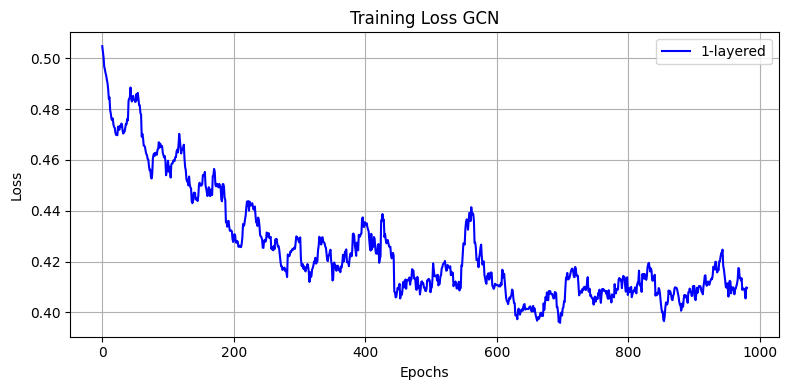

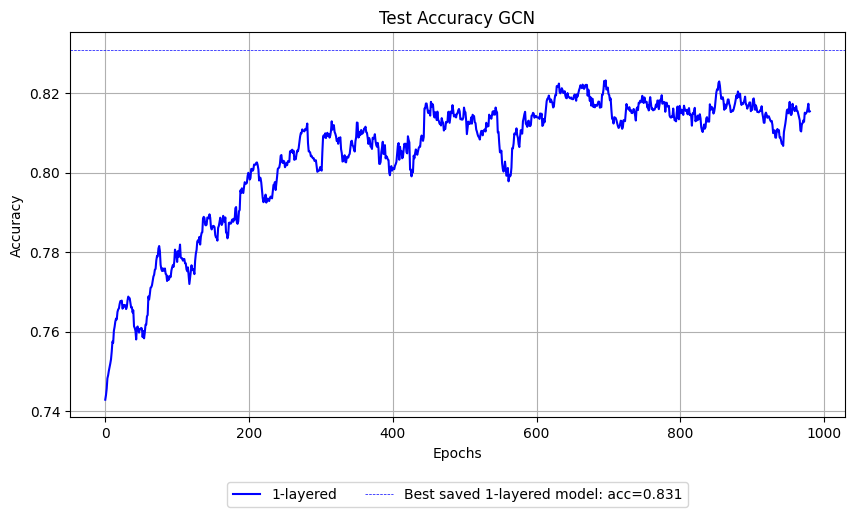

In [24]:
"""
You could enable smoothing.
We recommend smoothing if you train multiple model sizes and more complicated tasks.
"""

plot_history(gcn_history, 'GCN', 20, smoothe=True)
#plot_history(gat_history, 'GAT', 20)
#plot_history(gin_history, 'GIN', 20)